In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILE_PATH = Path("/n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/checks/bns_snr_8_20_uniform_256Hz_80K/val/sig_combined_val.h5")

keys = ["chirp_mass", "mass_ratio", "mass_1", "mass_2", "snr"]
data = {}

with h5py.File(FILE_PATH) as h5:
    for k in keys:
        data[k] = h5[k][:]

print(f"Loaded {len(data['mass_1'])} samples from {FILE_PATH}")
print(f"SNR range: {data['snr'].min():.2f} – {data['snr'].max():.2f}")

Loaded 20000 samples from /n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/checks/bns_snr_8_20_uniform_256Hz_80K/val/sig_combined_val.h5
SNR range: 8.00 – 20.00


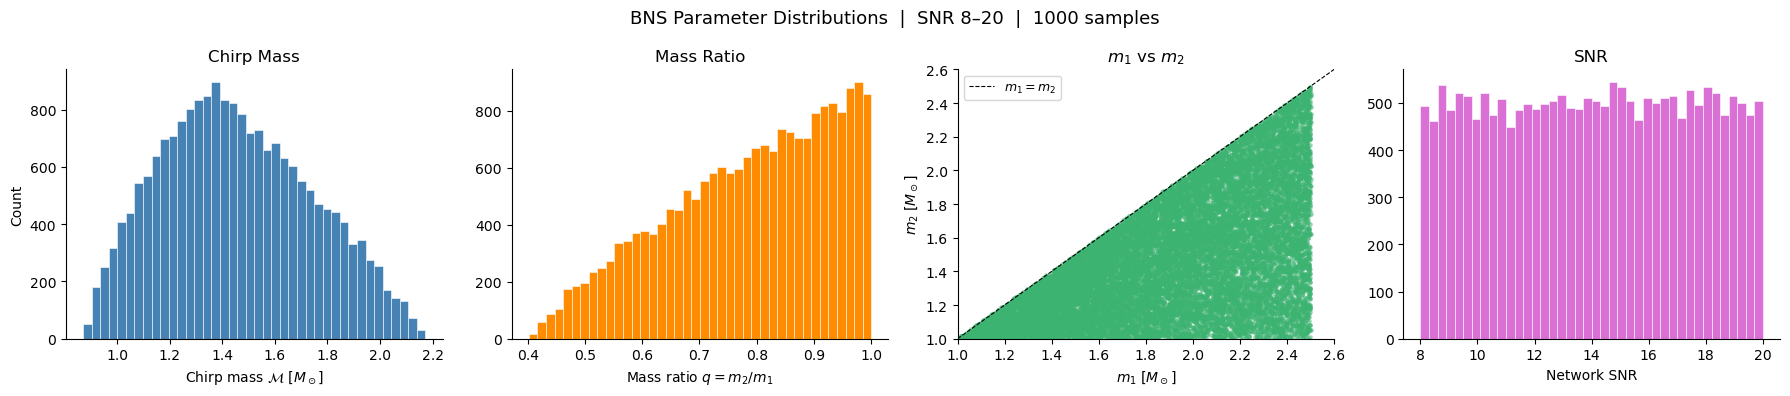

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("BNS Parameter Distributions  |  SNR 8–20  |  1000 samples", fontsize=13)

# Chirp mass
axes[0].hist(data["chirp_mass"], bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel(r"Chirp mass $\mathcal{M}$ [$M_\odot$]")
axes[0].set_ylabel("Count")
axes[0].set_title("Chirp Mass")

# Mass ratio q = m2/m1
axes[1].hist(data["mass_ratio"], bins=40, color="darkorange", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel(r"Mass ratio $q = m_2/m_1$")
axes[1].set_title("Mass Ratio")

# m1 vs m2 scatter
axes[2].scatter(data["mass_1"], data["mass_2"], s=6, alpha=0.4, color="mediumseagreen")
lims = [1.0, 2.6]
axes[2].plot(lims, lims, "k--", linewidth=0.8, label=r"$m_1 = m_2$")
axes[2].set_xlim(lims); axes[2].set_ylim(lims)
axes[2].set_xlabel(r"$m_1$ [$M_\odot$]")
axes[2].set_ylabel(r"$m_2$ [$M_\odot$]")
axes[2].set_title(r"$m_1$ vs $m_2$")
axes[2].legend(fontsize=9)

# SNR
axes[3].hist(data["snr"], bins=40, color="orchid", edgecolor="white", linewidth=0.4)
axes[3].set_xlabel("Network SNR")
axes[3].set_title("SNR")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()